# 5. Portfolio risk: what does changing dependence do to tail risk?

**What you will do**

1. Compute a portfolio's **Value at Risk (VaR)** and **Expected Shortfall (ES)** from a fitted vine.
2. Compare the vine with three simpler models that share the same marginals, to isolate the effect of dependence.
3. Follow risk over time and check the VaR against what actually happened (a *backtest*).
4. Relate risk to dependence, and learn how much of its variation is volatility rather than dependence.

**Definitions.** A portfolio with weights $w$ has return $R_p=\sum_i w_i r_i$ and loss $L=-R_p$.
$\mathrm{VaR}_{99\%}$ is the loss that is exceeded on only 1 % of days. $\mathrm{ES}_{99\%}=E[L\mid L\ge \mathrm{VaR}]$ is the average loss on those
worst days, so it always exceeds the VaR. Both are in return units (0.02 means 2 % of the portfolio value).

**Before you start:** notebook 3 (demo run) or the full run. **This is not a trading tool**; it studies how estimated tail risk
responds to dependence.

In [1]:
import os, warnings
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":      # notebooks run from the notebooks/ folder; the project root is one level up
    ROOT = ROOT.parent
os.chdir(ROOT)                    # all paths below are relative to the project folder
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.width", 140); pd.set_option("display.max_columns", 30)
print("working folder:", Path.cwd().name)

working folder: Quant_copula


In [2]:
from vine_risk.config import load_config
from vine_risk.pipeline import find_run, load_prices_and_returns
from vine_risk.rolling import load_results

cfg = load_config("configs/default.yaml")
prices, returns = load_prices_and_returns(cfg)
RUN = find_run()
results = load_results(RUN / "checkpoint.jsonl")
print(f"run: {RUN} | {len(results)} fits up to {results[-1].timestamp}")

def window_of(res):
    """The returns a stored fit was made on (the n_obs days ending on its date)."""
    end = returns.index.get_loc(pd.Timestamp(res.timestamp))
    return returns.iloc[end - res.n_obs + 1: end + 1]

run: data/results/w250 | 5222 fits up to 2026-10-02


## 5.1 Loss, VaR and Expected Shortfall by hand

For the plain historical estimate we just apply the definitions to the 250 real days of the latest window,
for an equal-weight portfolio of the eight assets:

In [3]:
from vine_risk.portfolio import portfolio_loss, var_es, equal_weights

res = results[-1]
win = window_of(res)
w = equal_weights(len(win.columns))
loss = portfolio_loss(w, win.to_numpy())              # L = -w'r, one number per day
var99, es99 = var_es(loss, alpha=0.99)
print("weights:", {c: round(float(x), 3) for c, x in zip(win.columns, w)})
print(f"historical 99% VaR {var99:.2%} | ES {es99:.2%} | based on only {(loss >= var99).sum()} days in the tail")

weights: {'AAPL': 0.125, 'MSFT': 0.125, 'NVDA': 0.125, 'JPM': 0.125, 'XOM': 0.125, 'JNJ': 0.125, 'SPY': 0.125, 'TLT': 0.125}
historical 99% VaR 1.52% | ES 1.81% | based on only 3 days in the tail


With 250 days, the 1 % tail is about **three days**. That is why a model is useful: it can generate thousands of scenarios.

## 5.2 Risk from the vine, compared with simpler models

`window_risk` rebuilds the fitted vine from the stored result (no refit needed), simulates 16,384 scenarios, maps them back to
returns through the window's own empirical distributions, and computes VaR and ES. It does the same for three benchmarks that use the
**same marginals** and the same random numbers, so any difference comes from the dependence only:

* **vine**: the fitted vine copula (with tail dependence where the data call for it);
* **Gaussian**: a Gaussian copula with the same correlations (no tail dependence);
* **independence**: assets treated as unrelated (the dependence is switched off);
* **historical**: the window's actual days.

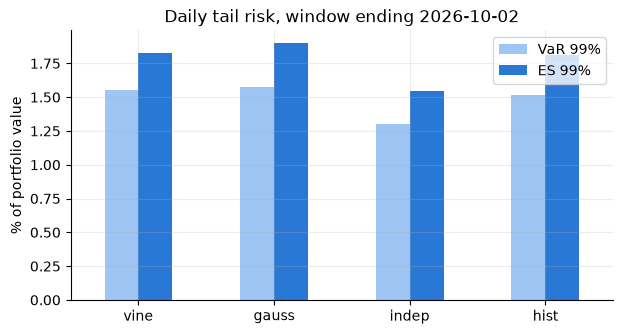

,VaR 99%,ES 99%
vine,1.56,1.83
gauss,1.58,1.90
indep,1.30,1.54
hist,1.52,1.81


In [4]:
from vine_risk.portfolio import window_risk

risk_now = window_risk(res, win, weights=w, alpha=0.99, n_sims=2**14, seed=42)
table = pd.DataFrame({"VaR 99%": {k[4:]: v for k, v in risk_now.items() if k.startswith("var_")},
                      "ES 99%": {k[3:]: v for k, v in risk_now.items() if k.startswith("es_")}})
fig, ax = plt.subplots(figsize=(7, 3.5))
(100 * table).plot.bar(ax=ax, rot=0, color=["#9ec5f4", "#2a78d6"]); ax.set_ylabel("% of portfolio value")
ax.set_title(f"Daily tail risk, window ending {res.timestamp}"); plt.show()
(100 * table).round(2)

Ignoring dependence (independence) understates the risk: by about a fifth in this calm window, and by a factor of two to three in the
crisis windows of 2008 and 2020 (section 5.4). Diversification is not what it looks like when assets crash together. The ratio
ES(vine) / ES(independence) is a clean measure of **how much dependence inflates tail risk**.

## 5.3 Your own portfolio

`weights` is just a list with one number per asset, in the order of the columns. For example 60 % SPY and 40 % TLT (stocks and
bonds), and nothing else:

In [5]:
my_w = np.array([0.6 if c == "SPY" else 0.4 if c == "TLT" else 0.0 for c in win.columns])
mine = window_risk(res, win, weights=my_w, alpha=0.99, n_sims=2**14, seed=42)
print("60/40 SPY/TLT:", {k: f"{100 * v:.2f}%" for k, v in mine.items() if k in ("var_vine", "es_vine", "es_gauss", "es_indep")})
print(f"dependence multiplier ES(vine)/ES(independence): equal-weight portfolio {risk_now['es_vine'] / risk_now['es_indep']:.2f}, "
      f"60/40 portfolio {mine['es_vine'] / mine['es_indep']:.2f}")

60/40 SPY/TLT: {'var_vine': '1.64%', 'es_vine': '1.94%', 'es_gauss': '1.85%', 'es_indep': '1.68%'}
dependence multiplier ES(vine)/ES(independence): equal-weight portfolio 1.18, 60/40 portfolio 1.16


Compare the two multipliers printed above: how much dependence inflates tail risk depends on the weights (and on the
period; stocks and bonds have sometimes been negatively related, in which case dependence can *reduce* the risk of a mix like this).
The weights can be set permanently in `configs/default.yaml` (`risk: weights:`), and the confidence level with `alpha`
(`risk: confidence_level:` in the config).

## 5.4 Risk over time

`rolling_risk` repeats this for many windows. For the full run the numbers have been computed by
`python scripts/compute_risk.py`; otherwise we compute them for the last 300 days here.

using the stored risk table: 1045 dates


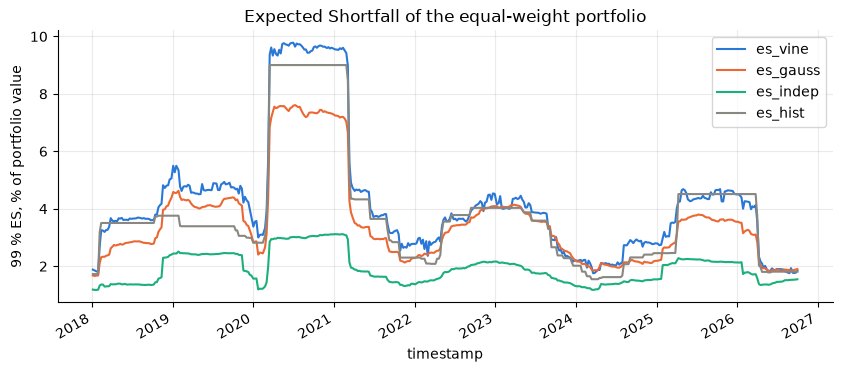

In [6]:
from vine_risk.portfolio import rolling_risk

stored = RUN / "portfolio_risk.parquet"
if stored.exists():
    risk = pd.read_parquet(stored); risk.index = pd.DatetimeIndex(risk.index)
    print("using the stored risk table:", len(risk), "dates")
else:
    subset = [r for r in results if pd.Timestamp(r.timestamp) >= returns.index[-300]]
    risk = rolling_risk(subset, returns, step=1, n_sims=2**13, n_jobs=4)
    print("computed", len(risk), "dates")

recent_risk = 100 * risk[["es_vine", "es_gauss", "es_indep", "es_hist"]].loc["2018":]
fig, ax = plt.subplots(figsize=(10, 4))
recent_risk.plot(ax=ax, lw=1.5, color=["#2a78d6", "#eb6834", "#1baf7a", "#898781"])
ax.set_ylabel("99 % ES, % of portfolio value"); ax.set_title("Expected Shortfall of the equal-weight portfolio"); plt.show()

## 5.5 Is the VaR any good? A backtest

If the model is right, tomorrow's loss should exceed today's 99 % VaR on about 1 % of days. `backtest_var` counts how often it does and
runs **Kupiec's test** (is the exceedance rate consistent with 1 %?).

In [7]:
from vine_risk.portfolio import backtest_var

bt = backtest_var(risk, returns, weights=w, alpha=0.99)
bt["rate"] = (100 * bt["rate"]).round(2)
bt.rename(columns={"rate": "exceedance rate (%)"}).round(3)

,n,exceedances,exceedance rate (%),expected_rate,kupiec_p
vine,1045.0,10.0,0.96,0.01,0.888
gauss,1045.0,16.0,1.53,0.01,0.110
indep,1045.0,58.0,5.55,0.01,0.000
hist,1045.0,17.0,1.63,0.01,0.062


Read the table like this: a rate close to 1 % and a **large** Kupiec p-value mean "no evidence of miscalibration". Independence
is clearly rejected. The vine, Gaussian copula and historical simulation are all plausible; with only a handful of exceedances the
test cannot separate them. **Do not read the vine's lower rate as proof that it is better**; the full comparison, including simulated
data where the truth is known, is in the validation study.

## 5.6 Dependence versus volatility

Tail risk rises in crises for two reasons: assets become more volatile, and they move together more. Dividing ES(vine) by ES(independence)
removes the volatility effect (same marginals in both) and leaves the dependence effect.

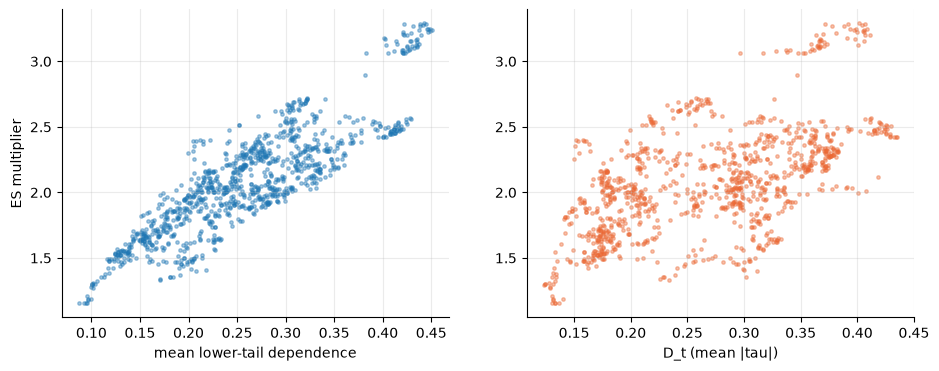

dependence multiplier (ES vine ÷ ES indep.)    1.00
mean lower-tail dependence                     0.87
D_t                                            0.58


In [8]:
from vine_risk.dependence import dependence_metrics

dm = dependence_metrics(results).reindex(risk.index)
both = pd.DataFrame({"dependence multiplier (ES vine ÷ ES indep.)": risk.es_dependence_ratio, "mean lower-tail dependence": dm.mean_lower_tail_q,
                     "D_t": dm.d_t}).dropna()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(both.iloc[:, 1], both.iloc[:, 0], s=6, alpha=.4); axes[0].set_xlabel("mean lower-tail dependence"); axes[0].set_ylabel("ES multiplier")
axes[1].scatter(both.iloc[:, 2], both.iloc[:, 0], s=6, alpha=.4, color="#eb6834"); axes[1].set_xlabel("D_t (mean |tau|)")
plt.show()
print(both.corr().iloc[0].round(2).to_string())

In [9]:
l = np.log(risk[["es_vine", "es_indep", "es_dependence_ratio"]])
parts = pd.Series({"volatility / marginals": l.es_indep.var(), "dependence multiplier": l.es_dependence_ratio.var(),
                   "both together (covariance)": 2 * l.es_indep.cov(l.es_dependence_ratio)})
print((parts / l.es_vine.var()).round(2).to_string())
print("(shares of the variance of log ES; they add to about 1)")

volatility / marginals        0.59
dependence multiplier         0.21
both together (covariance)    0.20
(shares of the variance of log ES; they add to about 1)


The multiplier tracks lower-tail dependence more closely than average correlation, but part of that is mechanical (both come from
the same fitted vines). The decomposition shows that most of the swings in ES come from **volatility**, with dependence a smaller but
real part; in crises the two rise together, so they cannot be cleanly separated. These are associations in this sample, not causal
statements.

## 5.7 Limitations to keep in mind

* A 99 % tail from 250 days rests on about three observations; individual dates are noisy.
* Simulated losses are capped at the window's worst observed day (empirical marginals), which understates extreme tails.
* ES was not backtested here (only VaR), and the comparison models are few and simple.
* Portfolio weights are fixed; there is no rebalancing, trading cost or short-selling logic.

Next: `06_live_monitor.ipynb`, running all of this one day at a time.